# <font color='blue'>Análisis de Datos en Python</font>
### <font color='red'>17 de octubre de 2025</font>
### Andrés Padrón Quintana 
### <font color='green'>Curso : DATA SCIENCE AND MACHINE LEARNING APPLIED TO FINANCIAL MARKETS </font>

### 1. Carga y análisis inicial

In [1]:
# Importamos librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE


In [2]:
# 1) Cargamos datos y  hacemos un diagnóstico
DATA_PATH = "german_credit_data.csv"  

df = pd.read_csv(DATA_PATH)

print("Dimensiones:", df.shape)
display(df.head(10))

print("\nTipos de datos:")
display(df.dtypes)

print("\nValores nulos por columna:")
display(df.isna().sum())

print("\nDuplicados:", df.duplicated().sum())

# Diccionario para la descripción
pd.DataFrame({
    "Descripción":[
        "Edad del solicitante.",
        "Sexo del solicitante.",
        "Nivel/Tipo de empleo.",
        "Situación de vivienda.",
        "Categoría de cuenta de ahorro.",
        "Categoría de cuenta corriente.",
        "Monto del crédito solicitado.",
        "Plazo en meses.",
        "Propósito del crédito.",
        "Variable objetivo (buen/mal crédito)."
    ]
}, index=["Edad","Sexo","Trabajo","Vivienda","Cuenta_Ahorro",
          "Cuenta_Corriente","Monto_Credito","Periodo_Meses","Tipo","Resultado"])


Dimensiones: (1000, 10)


,Edad,Sexo,Trabajo,Vivienda,Cuenta_Ahorro,Cuenta_Corriente,Monto_Credito,Periodo_Meses,Tipo,Resultado
0,67,0,calificados,propia,NaN,bajo,1169,6,radio/TV,1
1,22,1,calificados,propia,bajo,medio,5951,48,radio/TV,0
2,49,0,no_calificados_residentes,propia,bajo,NaN,2096,12,educacion,1
3,45,0,calificados,familiar,bajo,bajo,7882,42,mobiliario,1
4,53,0,calificados,familiar,bajo,bajo,4870,24,automotriz,0
5,35,0,no_calificados_residentes,familiar,NaN,NaN,9055,36,educacion,1
6,53,0,calificados,propia,muy_alto,NaN,2835,24,mobiliario,1
7,35,0,altamente_calificados,rentada,bajo,medio,6948,36,automotriz,1
8,61,0,no_calificados_residentes,propia,alto,NaN,3059,12,radio/TV,1
9,28,0,altamente_calificados,propia,bajo,medio,5234,30,automotriz,0



Tipos de datos:


Edad                 int64
Sexo                 int64
Trabajo             object
Vivienda            object
Cuenta_Ahorro       object
Cuenta_Corriente    object
Monto_Credito        int64
Periodo_Meses        int64
Tipo                object
Resultado            int64
dtype: object


Valores nulos por columna:


Edad                  0
Sexo                  0
Trabajo               0
Vivienda              0
Cuenta_Ahorro       183
Cuenta_Corriente    394
Monto_Credito         0
Periodo_Meses         0
Tipo                  0
Resultado             0
dtype: int64


Duplicados: 0


,Descripción
Edad,Edad del solicitante.
Sexo,Sexo del solicitante.
Trabajo,Nivel/Tipo de empleo.
Vivienda,Situación de vivienda.
Cuenta_Ahorro,Categoría de cuenta de ahorro.
Cuenta_Corriente,Categoría de cuenta corriente.
Monto_Credito,Monto del crédito solicitado.
Periodo_Meses,Plazo en meses.
Tipo,Propósito del crédito.
Resultado,Variable objetivo (buen/mal crédito).



<ul>
  <li><b>Observaciones:</b> <font color="royalblue"><b>1,000</b></font></li>
  <li><b>Variables:</b> <b>10</b> ( <b>3</b> numéricas, <b>6</b> categóricas ) + objetivo <code><b>Resultado</b></code></li>
  <li><b>Duplicados:</b> <font color="royalblue"><b>0</b></font></li>
  <li><b>Faltantes:</b> solo en <code><b>Cuenta_Ahorro</b></code> y <code><b>Cuenta_Corriente</b></code></li>
</ul>

<hr/>

<h3><font color="darkgreen">Estructura de variables</font></h3>
<p>
  <b>Numéricas:</b> <code>Edad</code>, <code>Monto_Credito</code>, <code>Periodo_Meses</code><br/>
  <b>Categóricas:</b> <code>Sexo</code>, <code>Trabajo</code>, <code>Vivienda</code>, <code>Cuenta_Ahorro</code>, <code>Cuenta_Corriente</code>, <code>Tipo</code><br/>
  <b>Objetivo:</b> <code>Resultado</code> <i>(buen/mal)</i>
</p>
<p>
  <b>Nota:</b> aunque <code>Sexo</code> está codificada como 0/1, <b>se tratará como categórica binaria</b> (no numérica).
</p>

<hr/>

<h3><font color="darkgreen">Valores faltantes</font></h3>

<table>
  <thead>
    <tr>
      <th align="left"><b>Variable</b></th>
      <th align="right"><b>Faltantes</b></th>
      <th align="right"><b>% sobre 1,000</b></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><code>Cuenta_Ahorro</code></td>
      <td align="right"><font color="firebrick"><b>183</b></font></td>
      <td align="right"><font color="firebrick"><b>18.3%</b></font></td>
    </tr>
    <tr>
      <td><code>Cuenta_Corriente</code></td>
      <td align="right"><font color="firebrick"><b>394</b></font></td>
      <td align="right"><font color="firebrick"><b>39.4%</b></font></td>
    </tr>
    <tr>
      <td><i>(resto)</i></td>
      <td align="right">0</td>
      <td align="right">0.0%</td>
    </tr>
  </tbody>
</table>

<p><b>Duplicados:</b> <font color="royalblue"><b>0</b></font></p>

<hr/>

<h3><font color="darkgreen">Implicaciones y decisiones</font></h3>
<ol>
  <li><b>Categóricas con NA:</b> imputar con valor explícito <b>“Desconocido”</b> (preserva la información del <i>missing</i>).</li>
  <li><b>Numéricas:</b> imputar con <b>mediana</b> (robusta a atípicos).</li>
  <li><b>Codificación:</b> aplicar <b>One-Hot Encoding</b> a todas las categóricas (incluida <code>Sexo</code>).</li>
  <li><b>Escalamiento:</b> estandarizar numéricas con <code>StandardScaler</code>.</li>
  <li><b>Desbalance:</b> verificar <code>Resultado</code> y, si aplica, usar <b>SMOTE</b> <u>solo en train</u> para evitar <i>leakage</i>.</li>
</ol>


### 2. Partición de datos: Train/Test

In [3]:
# Train/Test Split (70/30, estratificado)

from sklearn.model_selection import train_test_split

# Definimos columnas
num_cols = ["Edad", "Monto_Credito", "Periodo_Meses"]
cat_cols = ["Sexo", "Trabajo", "Vivienda", "Cuenta_Ahorro", "Cuenta_Corriente", "Tipo"]
target   = "Resultado"

X = df[num_cols + cat_cols].copy()

# Aseguramos que y sea binaria {0,1}
y_raw = df[target]

if y_raw.dtype == "O":
    # Caso etiquetas de texto
    mapper = {"buen": 0, "mal": 1, "good": 0, "bad": 1}
    y = y_raw.str.lower().map(mapper).astype(int)
else:
    # Caso numérico (esperado 0/1)
    uniques = pd.Series(y_raw.unique()).sort_values().to_list()
    if set(uniques) <= {0,1}:
        y = y_raw.astype(int)
    else:
        raise ValueError(f"El target '{target}' no es binario 0/1. Valores únicos: {uniques}")

# 3) Hacemos el split estratificado 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Reportamos
def pct(x): 
    return (100*x).round(2)

print("Shapes -> X_train, X_test:", X_train.shape, X_test.shape)
print()

print("Proporción clase positiva (Resultado=1):")
print("  Total:", round(y.mean(), 4))
print("  Train:", round(y_train.mean(), 4))
print("  Test :", round(y_test.mean(), 4))
print()

print("Conteos por clase (total/train/test):")
tot = y.value_counts().rename("total")
trn = y_train.value_counts().rename("train")
tst = y_test.value_counts().rename("test")
display(pd.concat([tot, trn, tst], axis=1).fillna(0).astype(int))

train = X_train.copy()
train[target] = y_train

Shapes -> X_train, X_test: (700, 9) (300, 9)

Proporción clase positiva (Resultado=1):
  Total: 0.7
  Train: 0.7
  Test : 0.7

Conteos por clase (total/train/test):


,total,train,test
Resultado,,,
1,700,490,210
0,300,210,90


<h3><font color="darkgreen">Resultados del split</font></h3>
<ul>
  <li><b>Shapes:</b> <code>X_train</code> = <b>(700, 9)</b>, <code>X_test</code> = <b>(300, 9)</b></li>
  <li><b>Proporción clase positiva</b> (<code>Resultado = 1</code>):
    <ul>
      <li><b>Total:</b> <font color="royalblue"><b>0.70</b></font></li>
      <li><b>Train:</b> <font color="royalblue"><b>0.70</b></font></li>
      <li><b>Test:</b> <font color="royalblue"><b>0.70</b></font></li>
    </ul>
  </li>
</ul>

<table>
  <thead>
    <tr>
      <th align="left"><b>Clase</b></th>
      <th align="right"><b>Total</b></th>
      <th align="right"><b>Train</b></th>
      <th align="right"><b>Test</b></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><code>Resultado = 1</code></td>
      <td align="right"><b>700</b></td>
      <td align="right"><b>490</b></td>
      <td align="right"><b>210</b></td>
    </tr>
    <tr>
      <td><code>Resultado = 0</code></td>
      <td align="right">300</td>
      <td align="right">210</td>
      <td align="right">90</td>
    </tr>
  </tbody>
</table>

<hr/>

<h3><font color="darkgreen">Interpretación</font></h3>
<ul>
  <li>La <b>estratificación</b> funcionó: la proporción de la clase positiva se mantiene en <b>0.70</b> en total, train y test.</li>
  <li>Existe <b>desbalance</b> (70% vs. 30%), lo cual puede sesgar precisión y umbral por defecto (0.5). En los siguientes pasos se contemplará <b>SMOTE</b> sobre <i>Train</i> y/o ajuste de umbral.</li>
  <li>Los tamaños (700/300) son adecuados para entrenamiento y evaluación final.</li>
</ul>


### 3. Análisis exploratorio de datos (EDA)

Dimensiones TRAIN: (700, 10)

=== Resumen numéricas (describe) ===


,count,mean,std,min,25%,50%,75%,max
Edad,700.0,35.402857,11.242826,20.0,27.0,33.0,41.25,75.0
Monto_Credito,700.0,3236.121429,2809.268797,250.0,1336.0,2290.0,3965.25,18424.0
Periodo_Meses,700.0,21.048571,12.286887,4.0,12.0,18.0,24.00,72.0


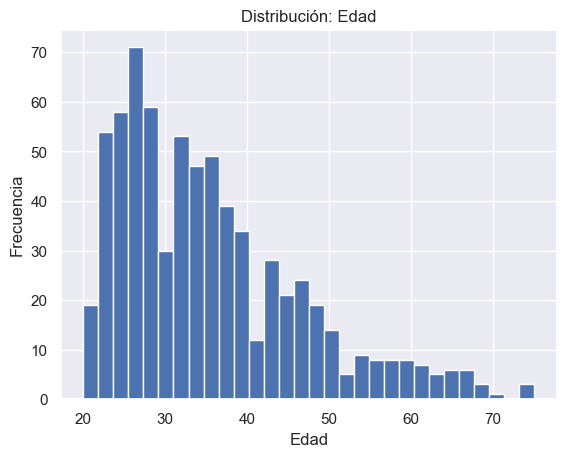

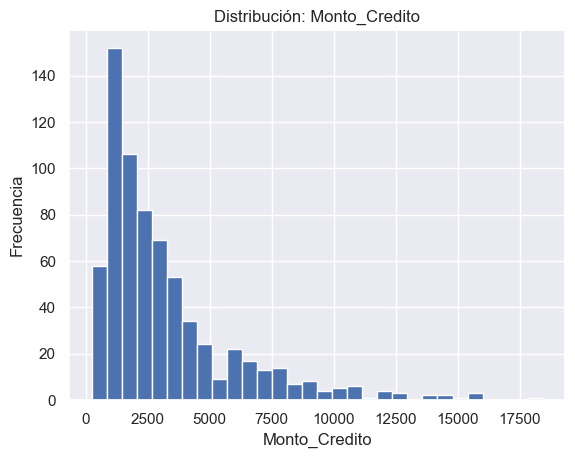

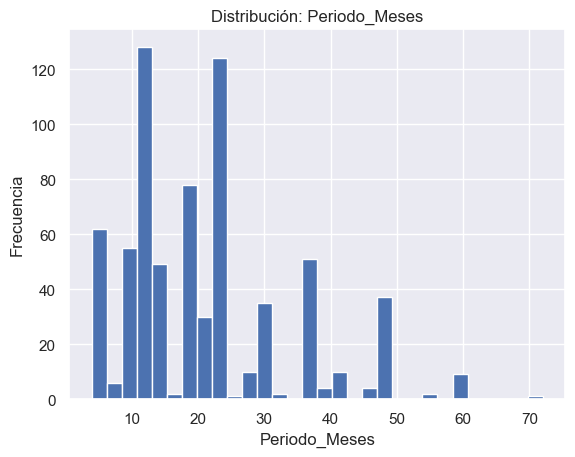

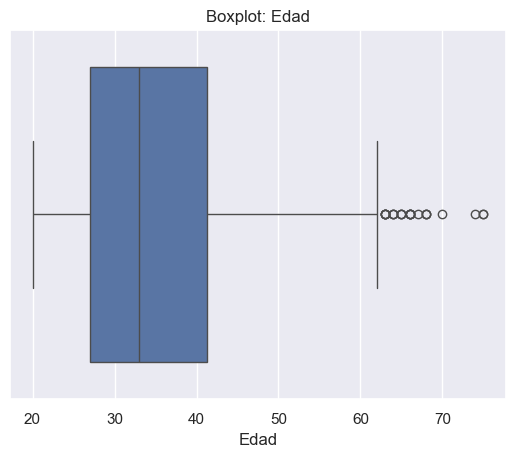

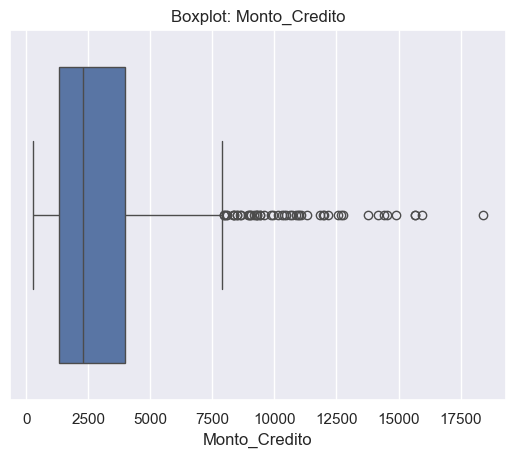

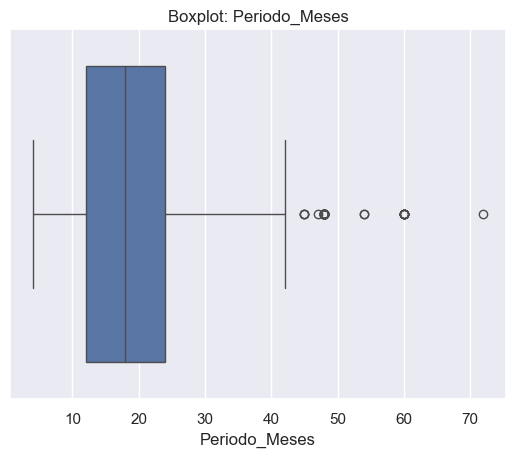


=== Frecuencias categóricas ===

--- Sexo ---


,conteo,porcentaje
Sexo,,
0,486,0.694
1,214,0.306


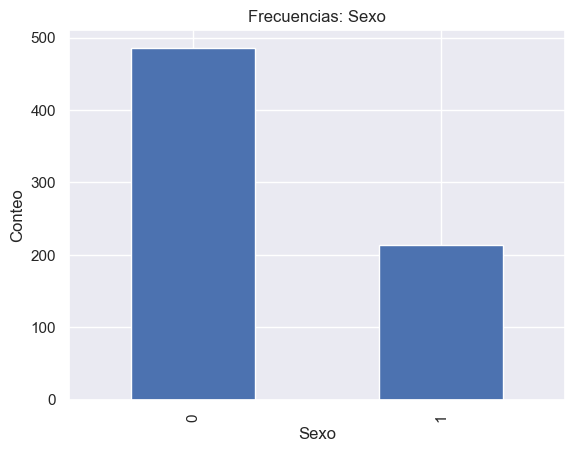


--- Trabajo ---


,conteo,porcentaje
Trabajo,,
calificados,448,0.640
no_calificados_residentes,133,0.190
altamente_calificados,104,0.149
no_calificados_no_residentes,15,0.021


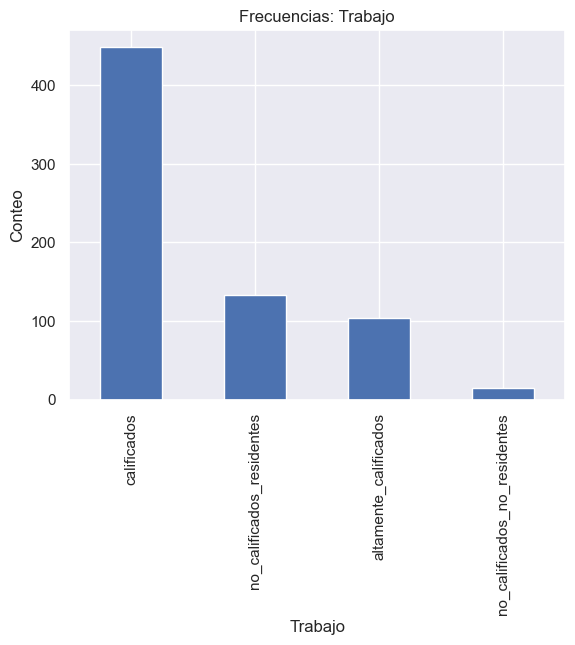


--- Vivienda ---


,conteo,porcentaje
Vivienda,,
propia,504,0.720
rentada,122,0.174
familiar,74,0.106


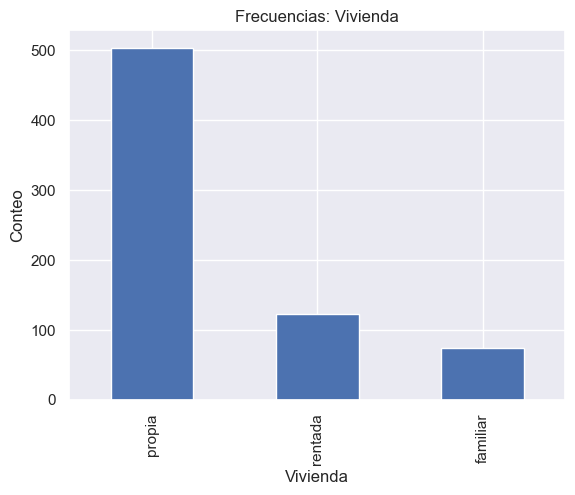


--- Cuenta_Ahorro ---


,conteo,porcentaje
Cuenta_Ahorro,,
bajo,428,0.611
NaN,125,0.179
intermedio,78,0.111
muy_alto,36,0.051
alto,33,0.047


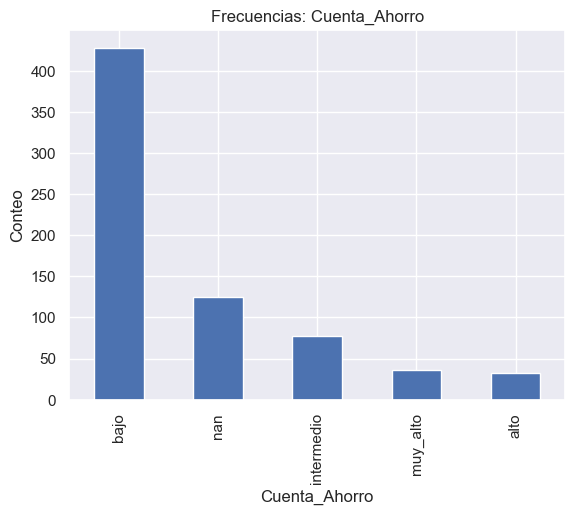


--- Cuenta_Corriente ---


,conteo,porcentaje
Cuenta_Corriente,,
NaN,274,0.391
bajo,201,0.287
medio,179,0.256
alto,46,0.066


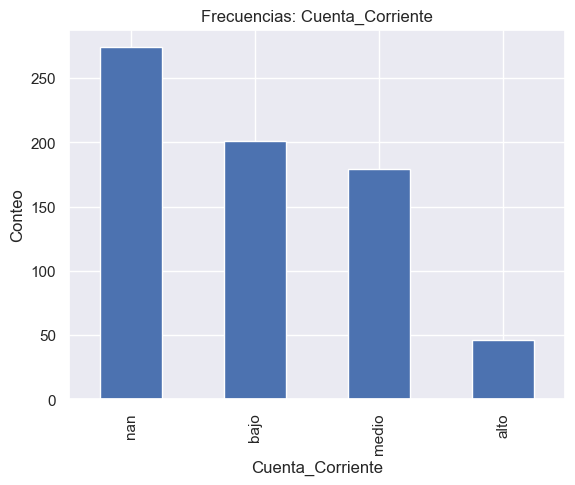


--- Tipo ---


,conteo,porcentaje
Tipo,,
automotriz,230,0.329
radio/TV,195,0.279
mobiliario,137,0.196
trabajo,67,0.096
educacion,39,0.056
reparaciones,17,0.024
vacaciones,8,0.011
uso_domestico,7,0.010


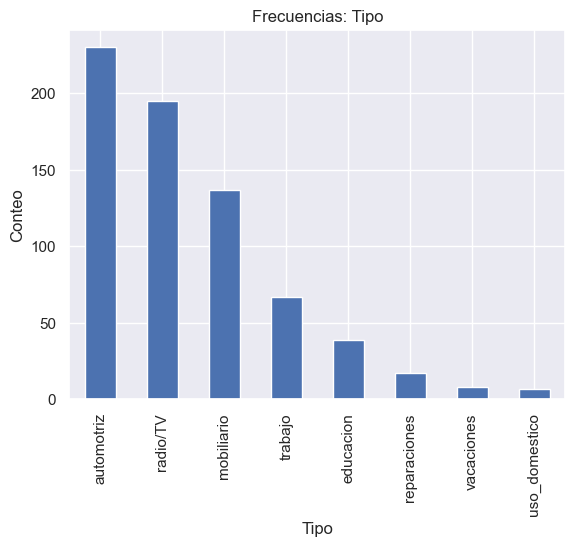

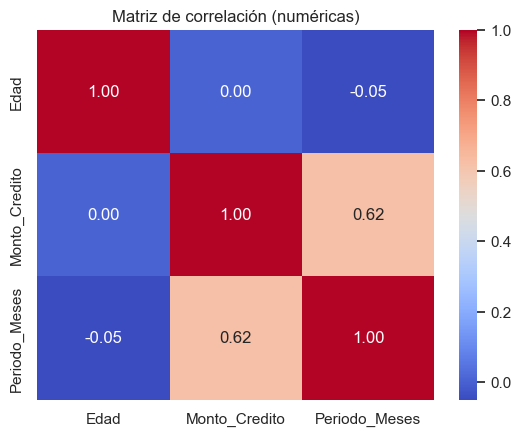


=== Medias de numéricas por clase (Resultado) ===


Resultado,0,1
Edad,33.68,36.14
Monto_Credito,3932.75,2937.57
Periodo_Meses,25.10,19.31



=== Categóricas condicionadas a Resultado (proporciones por clase) ===

--- Sexo ---


,Clase,Categoria,porcentaje
0,0,0,0.638095
1,0,1,0.361905
2,1,0,0.718367
3,1,1,0.281633



--- Trabajo ---


...

,Clase,Categoria,porcentaje
1,0,bajo,0.822581
2,0,intermedio,0.134409
3,0,muy_alto,0.026882
0,0,alto,0.016129
5,1,bajo,0.706941
6,1,intermedio,0.136247
7,1,muy_alto,0.079692
4,1,alto,0.077121



--- Cuenta_Corriente ---


,Clase,Categoria,porcentaje
1,0,bajo,0.553672
2,0,medio,0.389831
0,0,alto,0.056497
5,1,medio,0.441767
4,1,bajo,0.413655
3,1,alto,0.144578



--- Tipo ---


,Clase,Categoria,porcentaje
0,0,automotriz,0.342857
2,0,mobiliario,0.214286
3,0,radio/TV,0.180952
5,0,trabajo,0.119048
1,0,educacion,0.080952
4,0,reparaciones,0.033333
7,0,vacaciones,0.019048
6,0,uso_domestico,0.009524
8,1,automotriz,0.322449
11,1,radio/TV,0.320408


In [7]:
# EDA sobre TRAIN

import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# Armamos TRAIN sin duplicar la columna 'Resultado'
eda_train = X_train.copy()
if "Resultado" in eda_train.columns:
    eda_train = eda_train.drop(columns=["Resultado"])
eda_train = eda_train.assign(Resultado=y_train.values)

print("Dimensiones TRAIN:", eda_train.shape)

# Resumen de variables numéricas
print("\n=== Resumen numéricas (describe) ===")
display(eda_train[["Edad","Monto_Credito","Periodo_Meses"]].describe().T)

# Histogramas de las variables numéricas
for col in ["Edad","Monto_Credito","Periodo_Meses"]:
    plt.figure()
    eda_train[col].hist(bins=30)
    plt.title(f"Distribución: {col}")
    plt.xlabel(col); plt.ylabel("Frecuencia")
    plt.show()

# Boxplots (con esto detectamos outliers)
for col in ["Edad","Monto_Credito","Periodo_Meses"]:
    plt.figure()
    sns.boxplot(x=eda_train[col])
    plt.title(f"Boxplot: {col}")
    plt.show()

# Frecuencias de categóricas
def freq_table(s):
    vc = s.value_counts(dropna=False)
    pct = (vc / vc.sum()).round(3)
    return pd.DataFrame({"conteo": vc, "porcentaje": pct})

cat_cols = ["Sexo","Trabajo","Vivienda","Cuenta_Ahorro","Cuenta_Corriente","Tipo"]

print("\n=== Frecuencias categóricas ===")
for col in cat_cols:
    print(f"\n--- {col} ---")
    display(freq_table(eda_train[col]).head(20))
    plt.figure()
    eda_train[col].value_counts(dropna=False).plot(kind="bar")
    plt.title(f"Frecuencias: {col}")
    plt.xlabel(col); plt.ylabel("Conteo")
    plt.show()

# Correlación entre numéricas
plt.figure()
sns.heatmap(
    eda_train[["Edad","Monto_Credito","Periodo_Meses"]].corr(),
    annot=True, fmt=".2f", cmap="coolwarm"
)
plt.title("Matriz de correlación (numéricas)")
plt.show()

# Establecemos la relación con el objetivo
print("\n=== Medias de numéricas por clase (Resultado) ===")
num_by_y = eda_train.groupby("Resultado")[["Edad","Monto_Credito","Periodo_Meses"]].mean().T.round(2)
display(num_by_y)

print("\n=== Categóricas condicionadas a Resultado (proporciones por clase) ===")
for col in cat_cols:
    # crosstab evita el problema de reset_index/insert con el nombre 'Resultado'
    ctab = (
        pd.crosstab(eda_train["Resultado"], eda_train[col], normalize="index")
          .stack()
          .rename("porcentaje")
          .reset_index()
          .rename(columns={"Resultado": "Clase", col: "Categoria"})
    )
    resumen = (
        ctab.sort_values(by=["Clase", "porcentaje"], ascending=[True, False])
            .groupby("Clase", group_keys=False)
            .head(10)
    )
    print(f"\n--- {col} ---")
    display(resumen)


<h3><font color="darkgreen">3.1 Resumen de variables numéricas</font></h3>

<table>
  <thead>
    <tr>
      <th align="left"><b>Variable</b></th>
      <th align="right">Media</th>
      <th align="right">Desv.</th>
      <th align="right">Mín</th>
      <th align="right">Q1</th>
      <th align="right">Mediana</th>
      <th align="right">Q3</th>
      <th align="right">Máx</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><code>Edad</code></td>
      <td align="right">35.40</td>
      <td align="right">11.24</td>
      <td align="right">20</td>
      <td align="right">27</td>
      <td align="right">33</td>
      <td align="right">41.25</td>
      <td align="right">75</td>
    </tr>
    <tr>
      <td><code>Monto_Credito</code></td>
      <td align="right">3,236.12</td>
      <td align="right">2,809.27</td>
      <td align="right">250</td>
      <td align="right">1,336</td>
      <td align="right">2,290</td>
      <td align="right">3,965.25</td>
      <td align="right">18,424</td>
    </tr>
    <tr>
      <td><code>Periodo_Meses</code></td>
      <td align="right">21.05</td>
      <td align="right">12.29</td>
      <td align="right">4</td>
      <td align="right">12</td>
      <td align="right">18</td>
      <td align="right">24</td>
      <td align="right">72</td>
    </tr>
  </tbody>
</table>

<ul>
  <li><b>Monto_Credito</b> muestra <i>cola derecha</i> (mediana 2,290 vs. máx 18,424) → se esperan atípicos altos.</li>
  <li><b>Periodo_Meses</b> concentrado en múltiplos típicos (12, 18, 24, 36…).</li>
</ul>

<hr/>

<h3><font color="darkgreen">Frecuencias de categóricas (Train)</font></h3>

<ul>
  <li><b>Sexo:</b> 0 = 486 (69.4%), 1 = 214 (30.6%).</li>
  <li><b>Trabajo:</b> calificados 64.0%, no_calificados_residentes 19.0%, altamente_calificados 14.9%, no_calificados_no_residentes 2.1%.</li>
  <li><b>Vivienda:</b> propia 72.0%, rentada 17.4%, familiar 10.6%.</li>
  <li><b>Cuenta_Ahorro:</b> bajo 61.1%, <i>NaN</i> 17.9%, intermedio 11.1%, muy_alto 5.1%, alto 4.7%.</li>
  <li><b>Cuenta_Corriente:</b> <i>NaN</i> 39.1%, bajo 28.7%, medio 25.6%, alto 6.6%.</li>
  <li><b>Tipo:</b> automotriz 32.9%, radio/TV 27.9%, mobiliario 19.6%, trabajo 9.6%, educación 5.6%, reparaciones 2.4%, vacaciones 1.1%, uso_doméstico 1.0%.</li>
</ul>

<hr/>

<h3><font color="darkgreen">Relación con el objetivo</font></h3>

<p><b>Medias por clase (0 = “buen”, 1 = “mal”):</b></p>
<table>
  <thead>
    <tr>
      <th align="left"><b>Variable</b></th>
      <th align="right">Resultado=0</th>
      <th align="right">Resultado=1</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><code>Edad</code></td>
      <td align="right">33.68</td>
      <td align="right">36.14</td>
    </tr>
    <tr>
      <td><code>Monto_Credito</code></td>
      <td align="right">3,932.75</td>
      <td align="right">2,937.57</td>
    </tr>
    <tr>
      <td><code>Periodo_Meses</code></td>
      <td align="right">25.10</td>
      <td align="right">19.31</td>
    </tr>
  </tbody>
</table>

<ul>
  <li>Los <b>malos</b> tienden a ser <b>ligeramente mayores</b> (36.1 vs. 33.7).</li>
  <li>Los <b>buenos</b> piden <b>montos mayores</b> y a <b>plazos más largos</b> (podría reflejar perfil más solvente).</li>
</ul>

<p><b>Categóricas condicionadas a la clase (proporciones dentro de cada clase):</b></p>
<ul>
  <li><b>Sexo:</b> la categoría <code>0</code> domina tanto en buenos (63.8%) como en malos (71.8%).</li>
  <li><b>Vivienda:</b> “propia” es más frecuente en <b>malos</b> (75.7%) que en buenos (63.3%); “rentada” y “familiar” pesan más en <b>buenos</b>.</li>
  <li><b>Cuenta_Ahorro:</b> en <b>buenos</b> predomina “bajo” (82.3%); en <b>malos</b> también “bajo” (70.7%), pero con mayor presencia de “alto/muy_alto”.</li>
  <li><b>Cuenta_Corriente:</b> en <b>buenos</b> predominan “bajo/medio” (55.4%/38.98%); en <b>malos</b>, “medio” (44.2%) y “bajo” (41.4%), con más “alto” (14.5%).</li>
  <li><b>Tipo:</b> en <b>buenos</b> destaca “automotriz” (34.3%); en <b>malos</b>, “automotriz” (32.2%) y “radio/TV” (32.0%).</li>
</ul>

<hr/>

<h3><font color="darkgreen">Conclusiones EDA</font></h3>
<ul>
  <li>Distribuciones numéricas razonables; <b>Monto_Credito</b> presenta <b>asimetría y outliers altos</b>, por lo que el uso de <b>mediana</b> para imputación y <b>estandarización</b> es adecuado.</li>
  <li>Las cuentas (<b>ahorro</b> y <b>corriente</b>) concentran la <b>mayor parte de NA</b>; se mantendrá una categoría explícita <b>“Desconocido”</b> en el preprocesamiento.</li>
  <li>Se observan <b>diferencias por clase</b>: los “buenos” piden montos mayores y a plazos más largos; en categóricas, se aprecian cambios de mezcla por clase (p. ej., vivienda y tipo de crédito).</li>
  <li>Se confirma el <b>desbalance</b> 70/30 del objetivo, a considerar en modelado (SMOTE solo en <i>train</i> y/o ajuste de umbral).</li>
</ul>


### 4. Preprocesamiento de datos

In [8]:
# Preprocesamiento

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Definición de columnas (mismas del paso 2)
num_cols = ["Edad", "Monto_Credito", "Periodo_Meses"]
cat_cols = ["Sexo", "Trabajo", "Vivienda", "Cuenta_Ahorro", "Cuenta_Corriente", "Tipo"]

# Pipelines por tipo
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Desconocido")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(transformers=[
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

# Ajustamos con TRAIN y transformamos TRAIN/TEST
preprocess.fit(X_train)

Xtr = preprocess.transform(X_train)
Xte = preprocess.transform(X_test)

print("X_train transformado:", Xtr.shape)
print("X_test  transformado:", Xte.shape)

# Imprimimos nombres de columnas después del OHE
def get_feature_names(preprocess, num_cols, cat_cols):
    out = []
    # numéricas (se conservan nombres originales)
    out.extend(num_cols)
    # categóricas (expandidas por OHE)
    ohe = preprocess.named_transformers_["cat"].named_steps["ohe"]
    cat_expanded = ohe.get_feature_names_out(cat_cols).tolist()
    out.extend(cat_expanded)
    return out

feat_names = get_feature_names(preprocess, num_cols, cat_cols)
print("Total de features:", len(feat_names))
print("Primeras 20:", feat_names[:20])

# --- (Opcional) convertir a DataFrame para inspección rápida
Xtr_df = pd.DataFrame(Xtr, columns=feat_names, index=X_train.index)
Xte_df = pd.DataFrame(Xte, columns=feat_names, index=X_test.index)

# Vista rápida
display(Xtr_df.iloc[:5, :15])


X_train transformado: (700, 29)
X_test  transformado: (300, 29)
Total de features: 29
Primeras 20: ['Edad', 'Monto_Credito', 'Periodo_Meses', 'Sexo_0', 'Sexo_1', 'Trabajo_altamente_calificados', 'Trabajo_calificados', 'Trabajo_no_calificados_no_residentes', 'Trabajo_no_calificados_residentes', 'Vivienda_familiar', 'Vivienda_propia', 'Vivienda_rentada', 'Cuenta_Ahorro_Desconocido', 'Cuenta_Ahorro_alto', 'Cuenta_Ahorro_bajo', 'Cuenta_Ahorro_intermedio', 'Cuenta_Ahorro_muy_alto', 'Cuenta_Corriente_Desconocido', 'Cuenta_Corriente_alto', 'Cuenta_Corriente_bajo']


,Edad,Monto_Credito,Periodo_Meses,Sexo_0,Sexo_1,Trabajo_altamente_calificados,Trabajo_calificados,Trabajo_no_calificados_no_residentes,Trabajo_no_calificados_residentes,Vivienda_familiar,Vivienda_propia,Vivienda_rentada,Cuenta_Ahorro_Desconocido,Cuenta_Ahorro_alto,Cuenta_Ahorro_bajo
328,-0.391895,0.440600,1.217731,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
891,0.943243,-0.501243,-0.492631,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
255,-0.747932,1.489665,3.172429,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
243,-0.747932,-0.730649,-0.736968,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
492,-0.747932,-0.712125,-1.225643,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


<h3><font color="darkgreen">Resultado del pipeline</font></h3>
<ul>
  <li><b>X_train transformado:</b> <code>(700, 29)</code></li>
  <li><b>X_test transformado:</b> <code>(300, 29)</code></li>
  <li><b>Total de <i>features</i>:</b> <b>29</b></li>
  <li><b>Ejemplos de columnas generadas (OHE):</b> 
    <code>Sexo_0</code>, <code>Sexo_1</code>, 
    <code>Trabajo_altamente_calificados</code>, <code>Trabajo_calificados</code>, 
    <code>Trabajo_no_calificados_residentes</code>, 
    <code>Vivienda_familiar</code>, <code>Vivienda_propia</code>, <code>Vivienda_rentada</code>, 
    <code>Cuenta_Ahorro_Desconocido</code>, <code>Cuenta_Ahorro_alto</code>, <code>Cuenta_Ahorro_bajo</code>, 
    <code>Cuenta_Ahorro_intermedio</code>, <code>Cuenta_Ahorro_muy_alto</code>, 
    <code>Cuenta_Corriente_Desconocido</code>, <code>Cuenta_Corriente_alto</code>, <code>Cuenta_Corriente_bajo</code>, …
  </li>
</ul>

<hr/>

<h3><font color="darkgreen">Decisiones y justificación</font></h3>
<ol>
  <li><b>Imputación numéricas = mediana.</b> Es robusta ante outliers (ej. <code>Monto_Credito</code> con cola derecha) y evita desplazar el centro como podría ocurrir con la media.</li>
  <li><b>Imputación categóricas = “Desconocido”.</b> Se usa <code>SimpleImputer(strategy="constant", fill_value="Desconocido")</code> para <code>Cuenta_Ahorro</code> y <code>Cuenta_Corriente</code> (con NA altos). Esto mantiene un nivel explícito que puede ser informativo para el modelo.</li>
  <li><b>Codificación = One-Hot Encoding.</b> <code>OneHotEncoder(handle_unknown="ignore")</code> para todas las categóricas (incluida <code>Sexo</code>), evitando errores si aparece una categoría nueva en Test.</li>
  <li><b>Escalamiento = StandardScaler.</b> Estandariza <code>Edad</code>, <code>Monto_Credito</code>, <code>Periodo_Meses</code>, mejorando la estabilidad de modelos lineales y distancia/similitud.</li>
</ol>

<hr/>

<h3><font color="darkgreen">Buenas prácticas</font></h3>
<ul>
  <li><b>Sin fugas (no leakage):</b> el <b>ajuste del preprocesamiento</b> se hizo <u>solo con Train</u> y luego se aplicó a Test.</li>
  <li><b>Reproducibilidad:</b> mantener <code>random_state</code> fijo en el split; el pipeline permite integrarse después con validación cruzada.</li>
  <li><b>Interpretabilidad:</b> conservar los <i>feature names</i> expandidos para análisis de importancia o coeficientes.</li>
</ul>

<hr/>

<h3><font color="darkgreen">Conclusión</font></h3>
<p>
El conjunto queda representado por <b>29</b> variables transformadas (numéricas estandarizadas + dummies OHE)

### 5. Análisis de complejidad con Problexity

/Users/andrespadronquintana/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/andrespadronquintana/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


=== Métricas de complejidad (problexity 0.5.11) ===


,valor
c1,0.118709
c2,0.275862
clsCoef,0.697920
density,0.994645
f1,0.820245
f1v,0.455441
f2,0.580400
f3,0.984286
f4,0.968571
hubs,0.957290


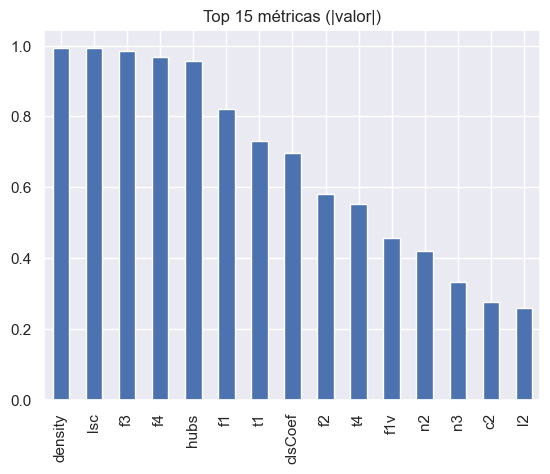

In [17]:
# Problexity

import inspect
import problexity as px

MEASURES = ["c1","c2","l1","l2","l3","n1","n2","n3","n4","t1","t2","t3","t4",
            "f1","f1v","f2","f3","f4","hubs","density","clsCoef","lsc"]

results = {}

# ComplexityCalculator
calc = getattr(px, "ComplexityCalculator", None)
if calc is not None and inspect.isclass(calc):
    try:
        cc = calc()
        cc.fit(Xtr, y_train.to_numpy())
        res_calc = cc.compute_all()  # muchos builds soportan compute_all()
        if isinstance(res_calc, dict) and len(res_calc) > 0:
            results.update(res_calc)
    except Exception:
        pass

# Llamamos funciones individuales 
for name in MEASURES:
    if name in results:
        continue
    fn = getattr(px, name, None)
    if fn is not None and callable(fn):
        try:
            results[name] = float(fn(Xtr, y_train.to_numpy()))
        except Exception:
            # algunos requieren kwargs; si falla, lo omitimos
            pass

# Mostramos resultados ordenados
if not results:
    raise RuntimeError("No se pudieron calcular medidas con esta build de problexity.")
compl_df = pd.Series(results, name="valor").to_frame().sort_index()
print("=== Métricas de complejidad (problexity 0.5.11) ===")
display(compl_df)

# Top por |valor| para visualizar rápido
try:
    topN = min(15, len(compl_df))
    compl_df.reindex(compl_df["valor"].abs().sort_values(ascending=False).head(topN).index)["valor"] \
            .plot(kind="bar", title=f"Top {topN} métricas (|valor|)")
except Exception:
    pass


<h3><font color="darkgreen">Métricas destacadas (TRAIN preprocesado)</font></h3>

<ul>
  <li><b>density</b> = <b>0.995</b>, <b>lsc</b> = <b>0.993</b>, <b>hubs</b> = <b>0.957</b> → alta <b>densidad local</b> y presencia de <b>nodos “hub”</b> en vecindarios; los datos forman cúmulos marcados.</li>
  <li><b>f3</b> = <b>0.984</b>, <b>f4</b> = <b>0.969</b>, <b>f1</b> = <b>0.820</b> → señales fuertes en el espacio de <b>features</b>; hay variables informativas pero con estructura no trivial.</li>
  <li><b>t1</b> = <b>0.731</b>, <b>t4</b> = <b>0.552</b> → <b>fronteras</b> de clase con cierta <b>irregularidad</b>/ramificación (no perfectamente suaves).</li>
  <li><b>clsCoef</b> = <b>0.698</b> → coeficiente de clasificación intermedio: separabilidad razonable, pero no simple.</li>
  <li><b>Familia N (vecindarios):</b> <b>n2</b> = <b>0.420</b>, <b>n3</b> = <b>0.333</b>, <b>n1</b> = <b>0.166</b>, <b>n4</b> = <b>0.187</b> → hay <b>solapamiento moderado</b> entre clases a nivel de vecinos más cercanos.</li>
  <li><b>Familia L (linealidad):</b> <b>l1</b> = <b>0.088</b>, <b>l2</b> = <b>0.259</b>, <b>l3</b> = <b>0.219</b> → evidencia de <b>separación poco lineal</b> (una frontera estrictamente lineal no captaría toda la estructura).</li>
  <li><b>c1</b> = <b>0.119</b>, <b>c2</b> = <b>0.276</b> → complejidad por compacidad/separación en niveles <b>bajos a medios</b>.</li>
</ul>

<hr/>

<h3><font color="darkgreen">Lectura e implicaciones</font></h3>
<ul>
  <li>El conjunto es <b>denso y clusterizado</b> (density/lsc altos) con <b>regiones de frontera irregulares</b> (t1–t4) y <b>solapamiento moderado</b> (familia N).</li>
  <li>Las métricas L bajas sugieren que un modelo estrictamente <b>lineal</b> puede ser una <b>línea base</b>, pero es probable que <b>métodos no lineales</b> (árboles/ensambles) o <b>ajustes de umbral</b> mejoren resultados.</li>
  <li>Con el <b>desbalance 70/30</b>, conviene aplicar <b>SMOTE</b> en <i>Train</i> y evaluar métricas sensibles a la clase minoritaria (recall/F1/PR-AUC).</li>
</ul>

### 6. Tratamiento del desbalance de clases

In [18]:
# Tratamiento del desbalance con SMOTE (sobre TRAIN preprocesado)

from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler

# Distribución original en TRAIN
print("Distribución original (TRAIN):")
dist_orig = y_train.value_counts().rename(index={0:"clase_0 (buen)", 1:"clase_1 (mal)"})
display(pd.DataFrame({"conteo": dist_orig, "porcentaje": (dist_orig/dist_orig.sum()).round(3)}))

# Elegimos método de remuestreo (SMOTE)
sampler = SMOTE(random_state=42, k_neighbors=5)   # ADASYN(random_state=42)  /  RandomOverSampler(random_state=42)

# Aplicamos SOLO en TRAIN preprocesado
Xtr_res, ytr_res = sampler.fit_resample(Xtr, y_train)

# Distribución tras remuestreo
print("\nDistribución tras SMOTE (TRAIN):")
dist_res = pd.Series(ytr_res).value_counts().rename(index={0:"clase_0 (buen)", 1:"clase_1 (mal)"})
display(pd.DataFrame({"conteo": dist_res, "porcentaje": (dist_res/dist_res.sum()).round(3)}))

# Imprimimos tamaños resultantes
print("\nShapes:")
print("  Xtr original:", Xtr.shape, "  y_train:", y_train.shape)
print("  Xtr_res    :", Xtr_res.shape, "  ytr_res :", ytr_res.shape)

# Inspección rápida de balance
print("\nProporción clase positiva (mal):")
print("  Antes:", round(y_train.mean(), 3), " — Después:", round(ytr_res.mean(), 3))

Distribución original (TRAIN):


,conteo,porcentaje
Resultado,,
clase_1 (mal),490,0.7
clase_0 (buen),210,0.3



Distribución tras SMOTE (TRAIN):


,conteo,porcentaje
Resultado,,
clase_1 (mal),490,0.5
clase_0 (buen),490,0.5



Shapes:
  Xtr original: (700, 29)   y_train: (700,)
  Xtr_res    : (980, 29)   ytr_res : (980,)

Proporción clase positiva (mal):
  Antes: 0.7  — Después: 0.5



<h3><font color="darkgreen">Distribución de clases</font></h3>

<table>
  <thead>
    <tr>
      <th align="left"><b>Conjunto</b></th>
      <th align="left"><b>Clase</b></th>
      <th align="right"><b>Conteo</b></th>
      <th align="right"><b>Proporción</b></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td rowspan="2">TRAIN (antes)</td>
      <td><code>clase_1 (mal)</code></td>
      <td align="right"><b>490</b></td>
      <td align="right"><b>0.70</b></td>
    </tr>
    <tr>
      <td><code>clase_0 (buen)</code></td>
      <td align="right">210</td>
      <td align="right">0.30</td>
    </tr>
    <tr>
      <td rowspan="2">TRAIN (después de <b>SMOTE</b>)</td>
      <td><code>clase_1 (mal)</code></td>
      <td align="right"><b>490</b></td>
      <td align="right"><b>0.50</b></td>
    </tr>
    <tr>
      <td><code>clase_0 (buen)</code></td>
      <td align="right"><b>490</b></td>
      <td align="right"><b>0.50</b></td>
    </tr>
  </tbody>
</table>

<p>
<b>Shapes:</b> <code>Xtr</code> <b>(700, 29)</b> → <code>Xtr_res</code> <b>(980, 29)</b>  
Proporción de positivos (<code>mal</code>): <b>antes 0.70</b> → <b>después 0.50</b>.
</p>

<hr/>

<h3><font color="darkgreen">Decisiones</font></h3>
<ul>
  <li>Se aplicó <b>SMOTE</b> (<code>k_neighbors=5</code>) <u>exclusivamente</u> sobre el conjunto <b>TRAIN</b> ya preprocesado (<i>para evitar leakage</i>).</li>
  <li>No se modificó <b>TEST</b>; se conserva para evaluación honesta.</li>
</ul>

<h3><font color="darkgreen">Implicaciones</font></h3>
<ul>
  <li>El balance 50/50 en <b>TRAIN</b> reduce el sesgo del modelo hacia la clase mayoritaria y mejora <b>recall</b> de la minoritaria.</li>
  <li>Como SMOTE sintetiza ejemplos en el espacio de <i>features</i>, es importante mantener el <b>pipeline</b> en el orden: <i>imputación → OHE → escalamiento → SMOTE → modelo</i>.</li>
  <li>Se recomienda validar con <b>CV estratificada</b> y reportar métricas sensibles a la clase minoritaria (Recall/F1/PR-AUC).</li>
</ul>

<p><i>Conclusión:</i> el desbalance original (70/30) quedó mitigado en TRAIN (50/50). Procedemos a entrenar un <b>modelo base</b> y evaluar en TEST.</p>
